# BFCL Cache & Latency Analysis
Comparative analysis of prompt caching and latency across providers.  
Covers hit rates, token composition, cached-token growth, block alignment, and per-call latency.

In [18]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
from pathlib import Path
BASE = Path(".")

RUNS = [
    {
        "label": "SambaNova PC",
        "result_dir": BASE / "result",
        "date": "2026-06-29T11:21:28",
    },
    {
        "label": "Sambanova Non PC",
        "result_dir": BASE / "result",
        "date": "2026-06-29T14:34:55",
    },
]

# Leave empty [] to include all discovered categories
CATEGORIES_FOCUS = ["simple", "multiple", "parallel_multiple","live_parallel","multi_turn_base", "multi_turn_long_context"]

# Block sizes to probe in the alignment chart
BLOCK_SIZES = [32, 64, 128, 256, 512, 1024, 4096]
# ──────────────────────────────────────────────────────────────────────────────

In [19]:
import json, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import defaultdict

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})


# ── shared helpers ────────────────────────────────────────────────────────────

def as_list(v):
    """Wrap scalars in a list; leave lists unchanged."""
    return v if isinstance(v, list) else [v]


def flatten(val):
    if isinstance(val, list):
        return sum(flatten(v) for v in val)
    return int(val or 0)


def flatten_paired(latencies, output_tokens):
    """Flat list of (latency_s, output_tokens) at per-step granularity."""
    if isinstance(latencies, list):
        pairs = []
        out_iter = output_tokens if isinstance(output_tokens, list) else [output_tokens] * len(latencies)
        for l, o in zip(latencies, out_iter):
            pairs.extend(flatten_paired(l, o))
        return pairs
    return [(float(latencies or 0), int(output_tokens or 0))]


def percentile(sorted_vals, pct):
    if not sorted_vals:
        return 0.0
    idx = int(len(sorted_vals) * pct / 100)
    return sorted_vals[min(idx, len(sorted_vals) - 1)]


def load_entries(path):
    entries = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    entries.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return entries


def per_turn_stats(entries):
    """Per-turn averages for tokens (cache) and latency.
    Handles both single-turn (scalar fields) and multi-turn (list-of-lists) entries.
    """
    max_turns = max((len(as_list(e.get("input_token_count", []))) for e in entries), default=0)
    rows = []
    for t in range(max_turns):
        inputs, cached, outputs, lats = [], [], [], []
        for e in entries:
            ic  = as_list(e.get("input_token_count", []))
            cc  = as_list(e.get("cached_token_count", []))
            oc  = as_list(e.get("output_token_count", []))
            lat = as_list(e.get("latency", []))
            if t < len(ic):
                inputs.append(flatten(ic[t]))
                cached.append(flatten(cc[t]) if t < len(cc) else 0)
                outputs.append(flatten(oc[t]) if t < len(oc) else 0)
                if t < len(lat):
                    step_lats = lat[t] if isinstance(lat[t], list) else [lat[t]]
                    lats.extend([float(x) for x in step_lats if x])
        if inputs:
            avg_i = sum(inputs)  / len(inputs)
            avg_c = sum(cached)  / len(cached)
            avg_o = sum(outputs) / len(outputs)
            avg_l = sum(lats)    / len(lats) if lats else 0
            tpot_vals = [avg_l / avg_o * 1000] if avg_o > 0 and avg_l > 0 else []
            rows.append({
                "turn":           t,
                "avg_input":      avg_i,
                "avg_cached":     avg_c,
                "avg_output":     avg_o,
                "avg_new":        avg_i - avg_c,
                "hit_rate":       avg_c / avg_i * 100 if avg_i > 0 else 0,
                "avg_latency":    avg_l,
                "avg_tpot_ms":    tpot_vals[0] if tpot_vals else 0,
                "avg_throughput": avg_o / avg_l if avg_l > 0 else 0,
                "n":              len(inputs),
            })
    return rows


def all_step_cached(entries):
    """Flat list of per-step cached token counts (> 0 only)."""
    vals = []
    for e in entries:
        ic = as_list(e.get("input_token_count", []))
        cc = as_list(e.get("cached_token_count", []))
        for t in range(len(ic)):
            steps_i = ic[t] if isinstance(ic[t], list) else [ic[t]]
            steps_c = cc[t] if (t < len(cc) and isinstance(cc[t], list)) else ([cc[t]] if t < len(cc) else [0] * len(steps_i))
            for tc in steps_c:
                if int(tc or 0) > 0:
                    vals.append(int(tc))
    return vals


def all_step_pairs(entries):
    """Flat (latency_s, output_tokens) for every API call."""
    pairs = []
    for e in entries:
        pairs.extend(flatten_paired(e.get("latency", 0), e.get("output_token_count", 0)))
    return [(l, o) for l, o in pairs if l > 0]


# ── load all runs ─────────────────────────────────────────────────────────────
DATA = []

for run in RUNS:
    result_dir = Path(run["result_dir"])
    date, label = run["date"], run["label"]
    for provider_dir in sorted(result_dir.iterdir()):
        date_dir = provider_dir / date
        if not date_dir.exists():
            continue
        for model_dir in sorted(date_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            for result_file in sorted(model_dir.glob("*_result.json")):
                category = result_file.stem.replace("BFCL_v3_", "").replace("_result", "")
                if CATEGORIES_FOCUS and category not in CATEGORIES_FOCUS:
                    continue
                entries = load_entries(result_file)
                if not entries:
                    continue
                DATA.append({
                    "label":       label,
                    "category":    category,
                    "entries":     entries,
                    "turn_stats":  per_turn_stats(entries),
                    "step_cached": all_step_cached(entries),
                    "step_pairs":  all_step_pairs(entries),
                })

categories = sorted({d["category"] for d in DATA})
run_labels = [r["label"] for r in RUNS]
print(f"Loaded {len(DATA)} dataset(s)")
for d in DATA:
    print(f"  {d['label']} / {d['category']} — {len(d['entries'])} entries, {len(d['step_pairs'])} API calls")

Loaded 12 dataset(s)
  SambaNova PC / live_parallel — 16 entries, 16 API calls
  SambaNova PC / multi_turn_base — 100 entries, 1027 API calls
  SambaNova PC / multi_turn_long_context — 100 entries, 1008 API calls
  SambaNova PC / multiple — 100 entries, 98 API calls
  SambaNova PC / parallel_multiple — 100 entries, 98 API calls
  SambaNova PC / simple — 100 entries, 99 API calls
  Sambanova Non PC / live_parallel — 16 entries, 16 API calls
  Sambanova Non PC / multi_turn_base — 100 entries, 1034 API calls
  Sambanova Non PC / multi_turn_long_context — 100 entries, 1043 API calls
  Sambanova Non PC / multiple — 100 entries, 98 API calls
  Sambanova Non PC / parallel_multiple — 100 entries, 93 API calls
  Sambanova Non PC / simple — 100 entries, 94 API calls


---
# Cache Analysis

## 1 · Overall cache hit rate by provider × category

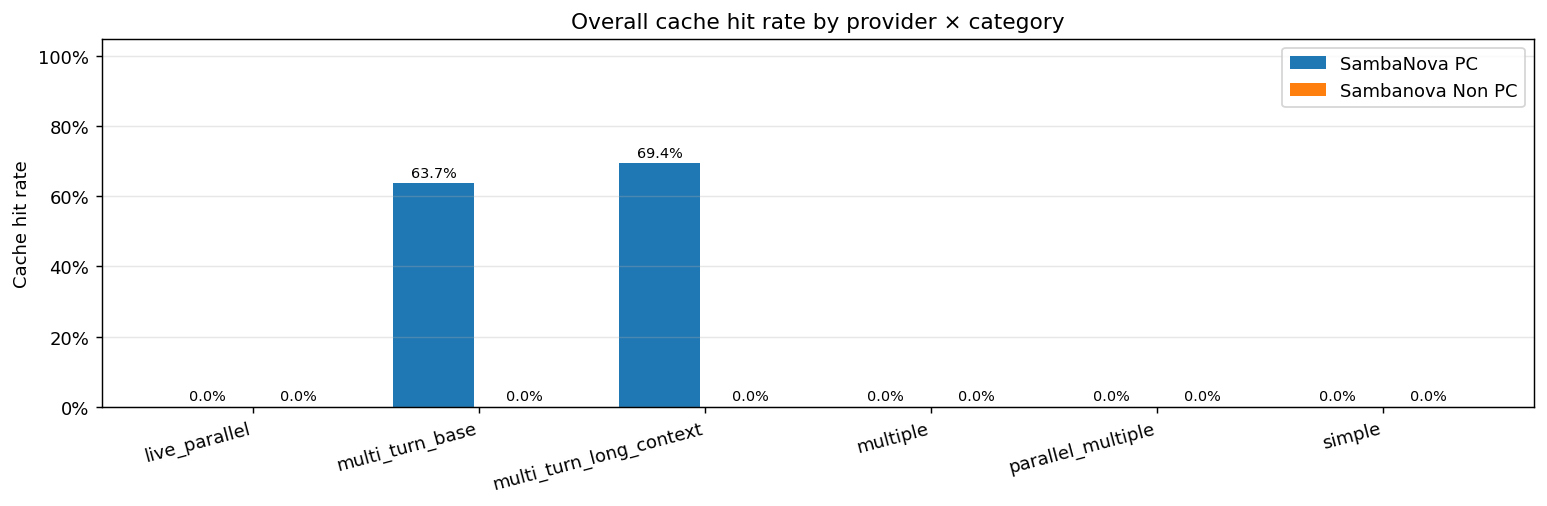

In [20]:
def overall_hit_rate(d):
    total_i = sum(flatten(e.get("input_token_count", 0)) for e in d["entries"])
    total_c = sum(flatten(e.get("cached_token_count", 0)) for e in d["entries"])
    return total_c / total_i * 100 if total_i > 0 else 0

x = np.arange(len(categories))
width = 0.8 / max(len(run_labels), 1)
fig, ax = plt.subplots(figsize=(max(7, len(categories) * 2), 4))

for i, lbl in enumerate(run_labels):
    rates = []
    for cat in categories:
        match = [d for d in DATA if d["label"] == lbl and d["category"] == cat]
        rates.append(overall_hit_rate(match[0]) if match else 0)
    offset = (i - len(run_labels) / 2 + 0.5) * width
    bars = ax.bar(x + offset, rates, width * 0.9, label=lbl)
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(categories, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 105); ax.set_ylabel("Cache hit rate")
ax.set_title("Overall cache hit rate by provider × category")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 2 · Cache hit rate per turn

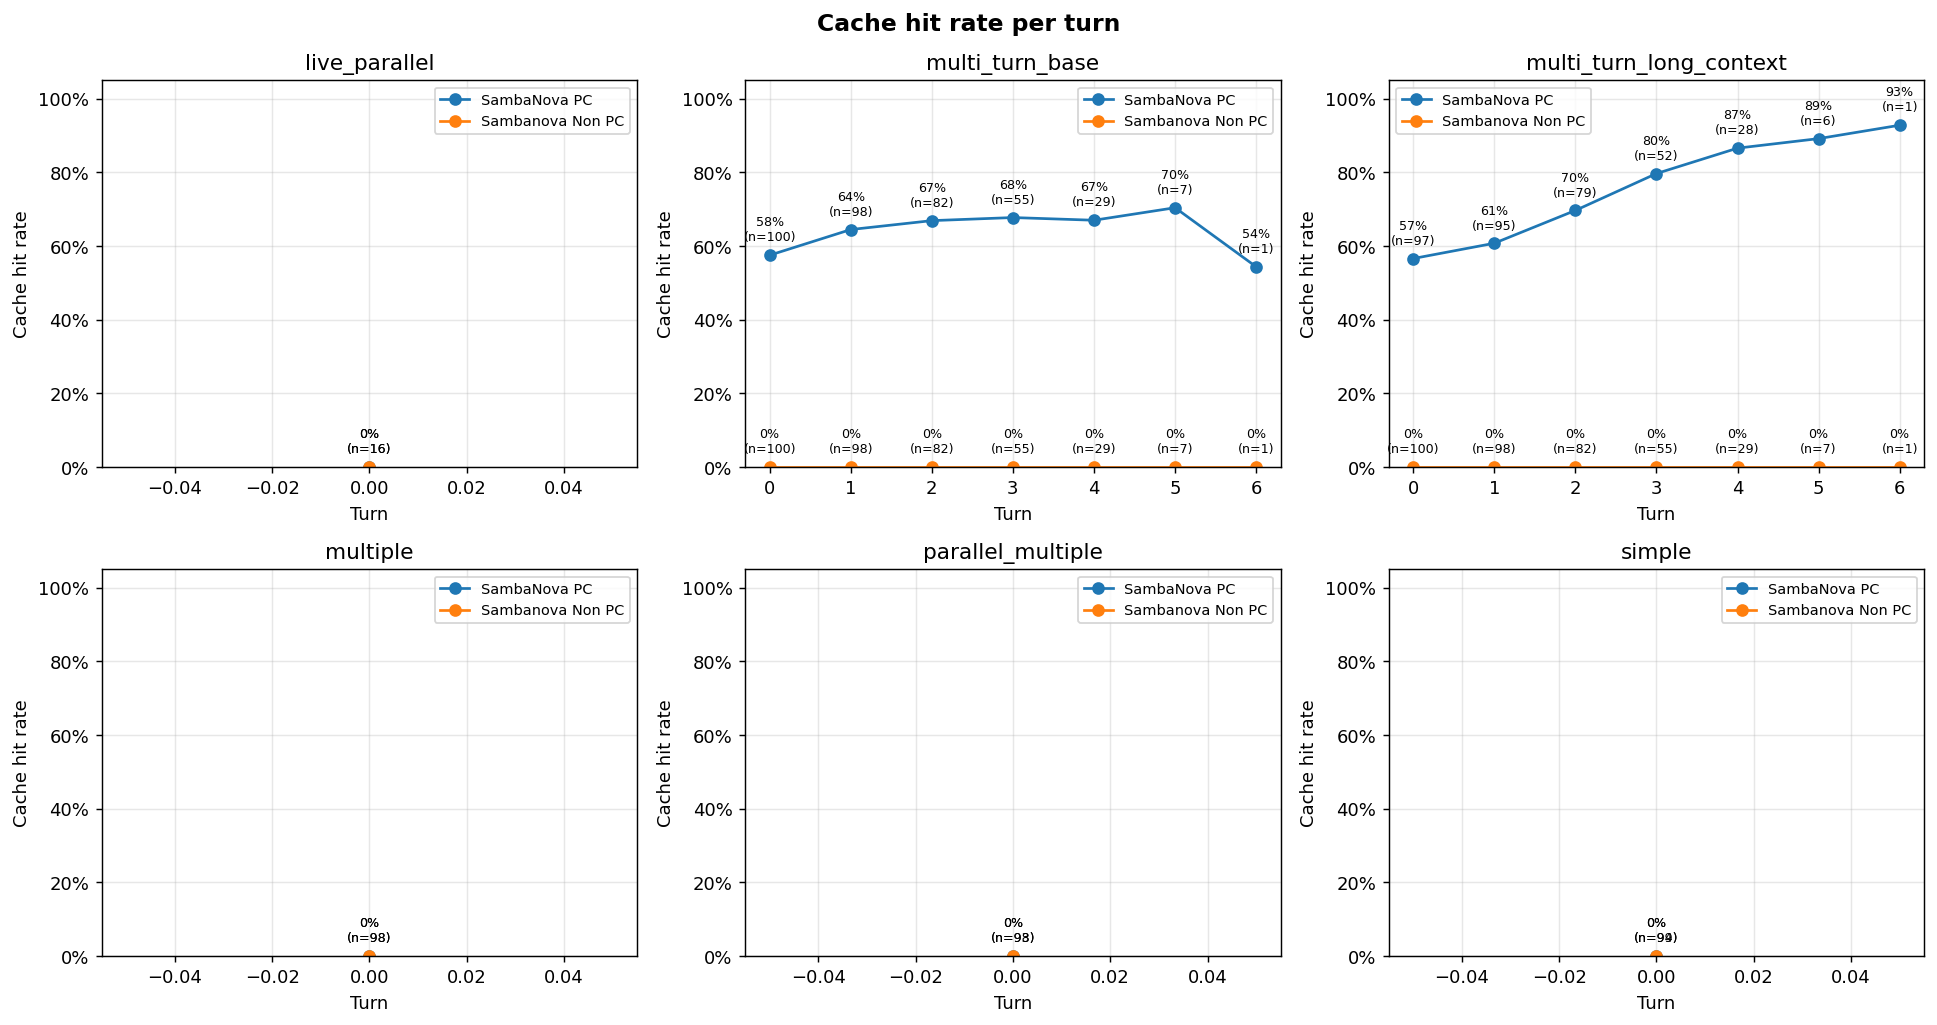

In [21]:
ncols = min(len(categories), 3)
nrows = math.ceil(len(categories) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for idx, cat in enumerate(categories):
    ax = axes[idx // ncols][idx % ncols]
    for d in DATA:
        if d["category"] != cat: continue
        ts = d["turn_stats"]
        turns = [r["turn"] for r in ts]
        rates = [r["hit_rate"] for r in ts]
        ns    = [r["n"] for r in ts]
        ax.plot(turns, rates, marker="o", label=d["label"])
        for t, r, n in zip(turns, rates, ns):
            ax.annotate(f"{r:.0f}%\n(n={n})", (t, r), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel("Turn"); ax.set_ylabel("Cache hit rate")
    ax.set_title(cat); ax.set_ylim(0, 105)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

for idx in range(len(categories), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)
fig.suptitle("Cache hit rate per turn", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 3 · Cached token growth per turn
Growing cached counts = session-affine KV reuse. Flat = no per-conversation persistence.

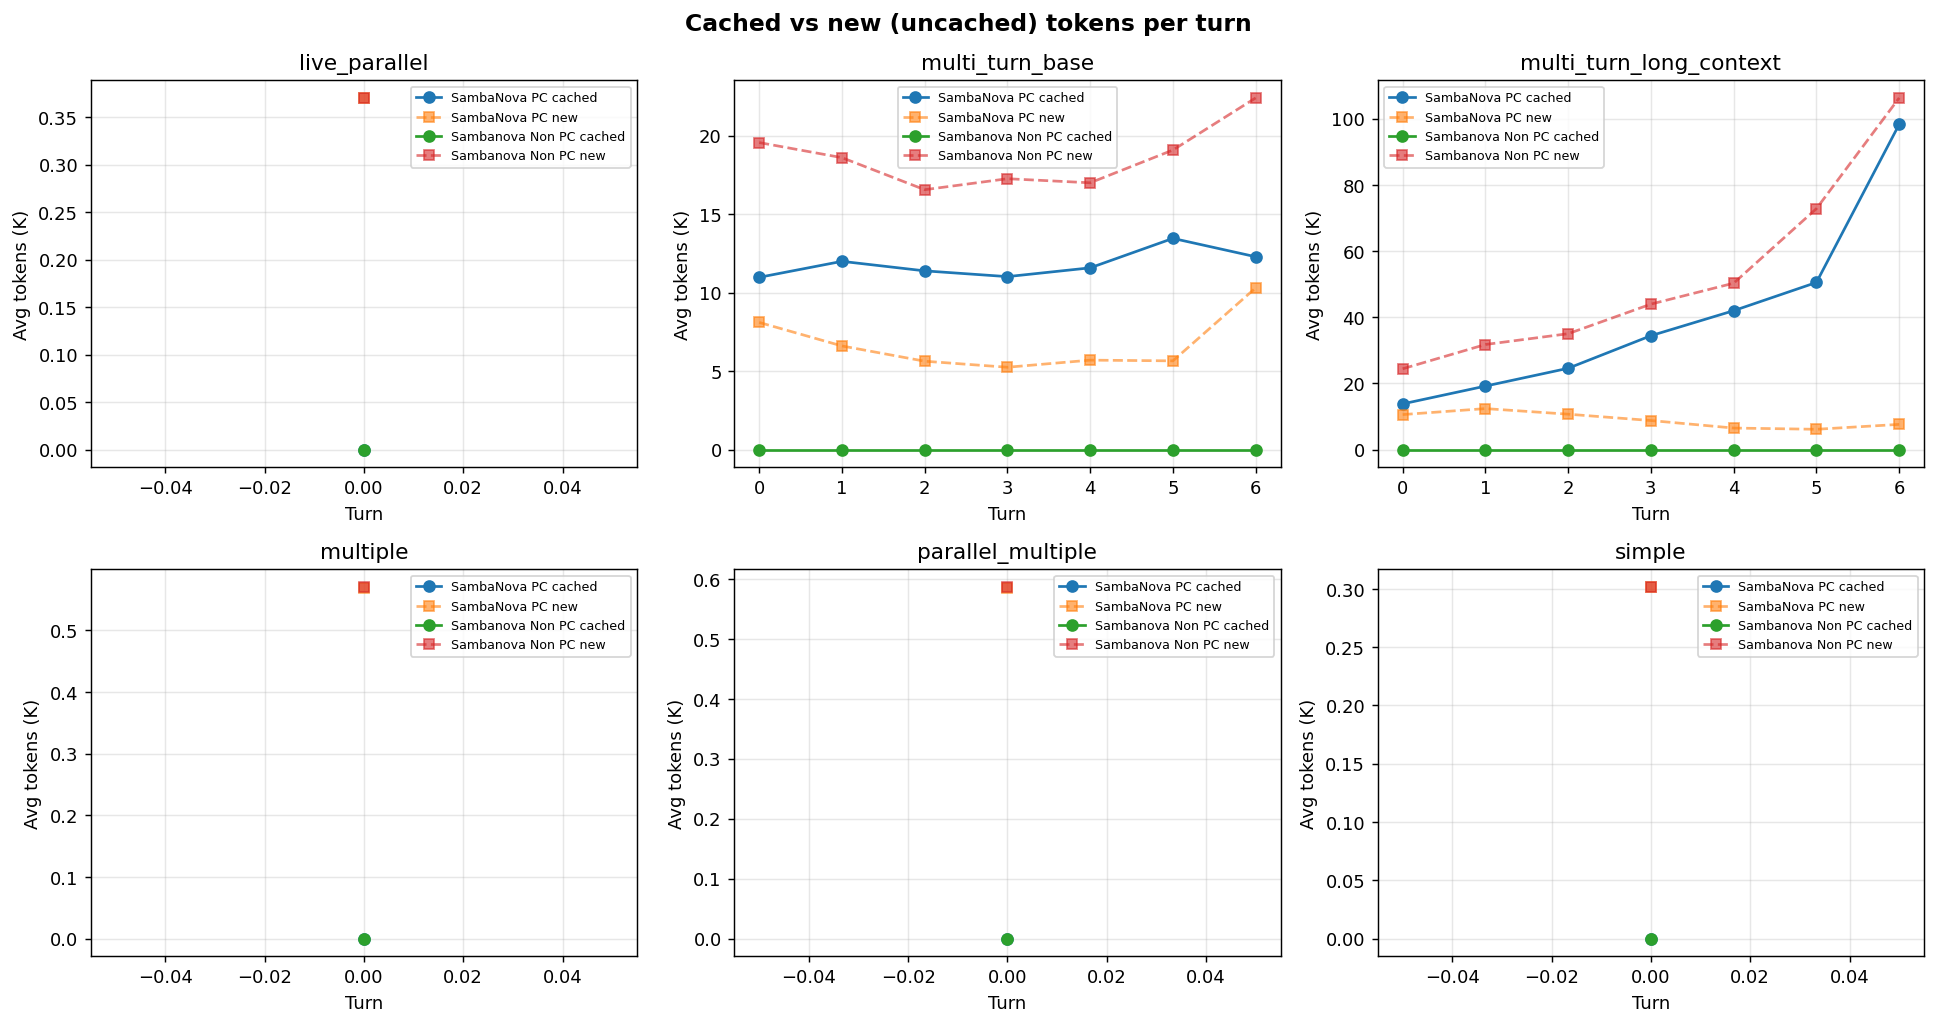

In [22]:
ncols = min(len(categories), 3)
nrows = math.ceil(len(categories) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for idx, cat in enumerate(categories):
    ax = axes[idx // ncols][idx % ncols]
    for d in DATA:
        if d["category"] != cat: continue
        ts = d["turn_stats"]
        turns  = [r["turn"]       for r in ts]
        cached = [r["avg_cached"] / 1000 for r in ts]
        new    = [r["avg_new"]    / 1000 for r in ts]
        ax.plot(turns, cached, marker="o", label=f"{d['label']} cached")
        ax.plot(turns, new,    marker="s", linestyle="--", alpha=0.6, label=f"{d['label']} new")
    ax.set_xlabel("Turn"); ax.set_ylabel("Avg tokens (K)")
    ax.set_title(cat); ax.legend(fontsize=7); ax.grid(alpha=0.3)

for idx in range(len(categories), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)
fig.suptitle("Cached vs new (uncached) tokens per turn", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 4 · Token composition per turn (stacked bar)

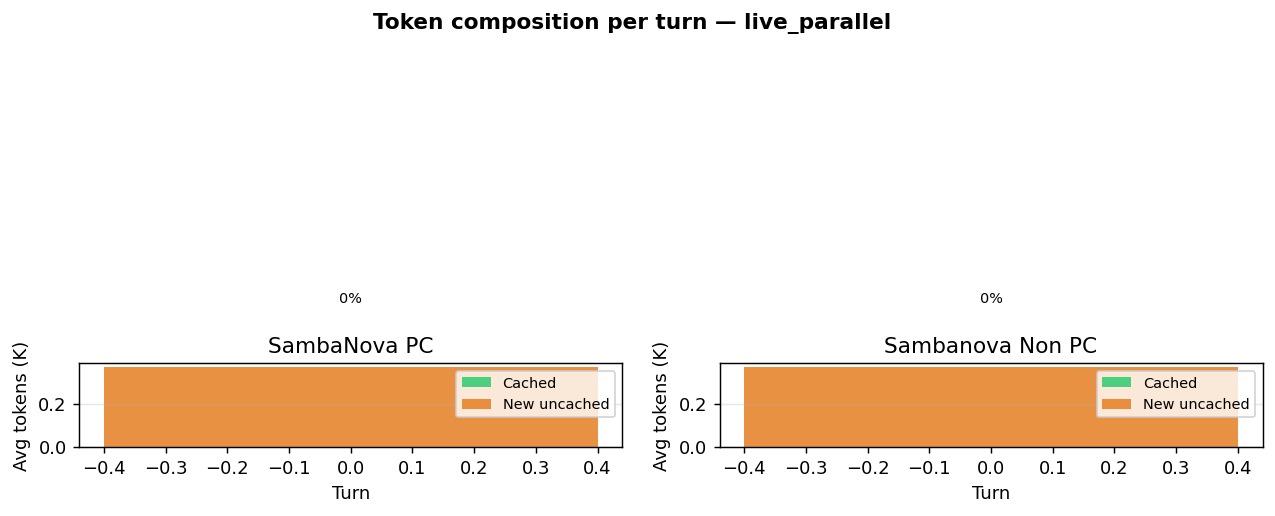

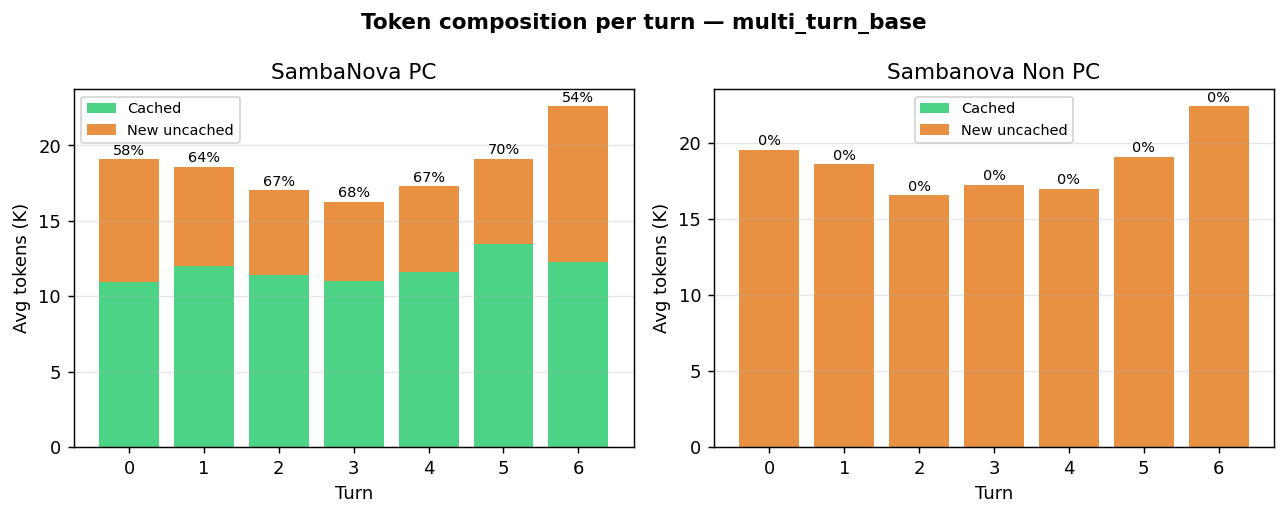

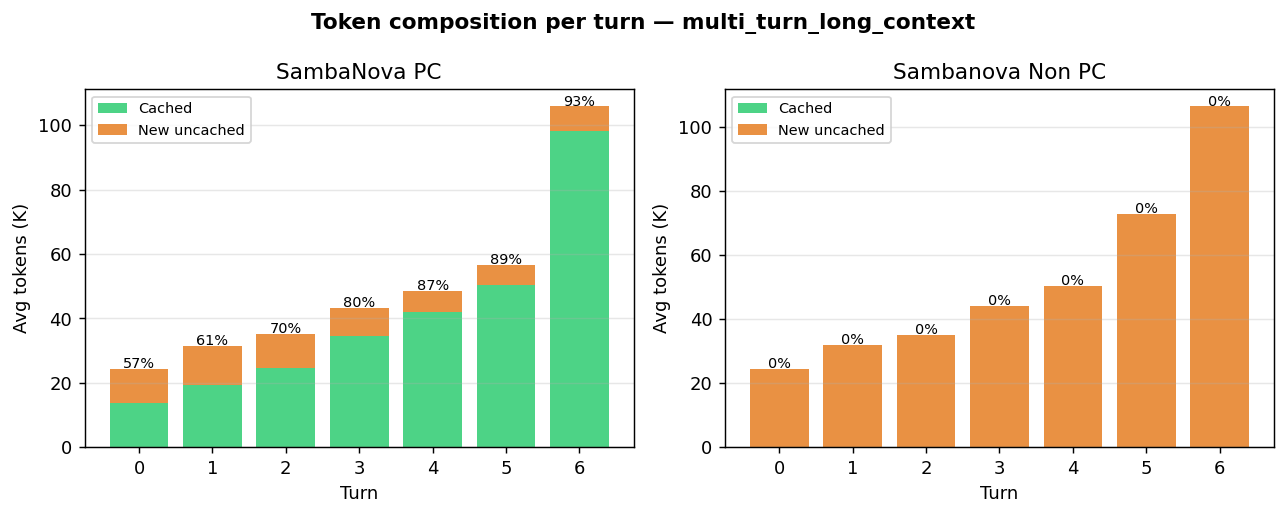

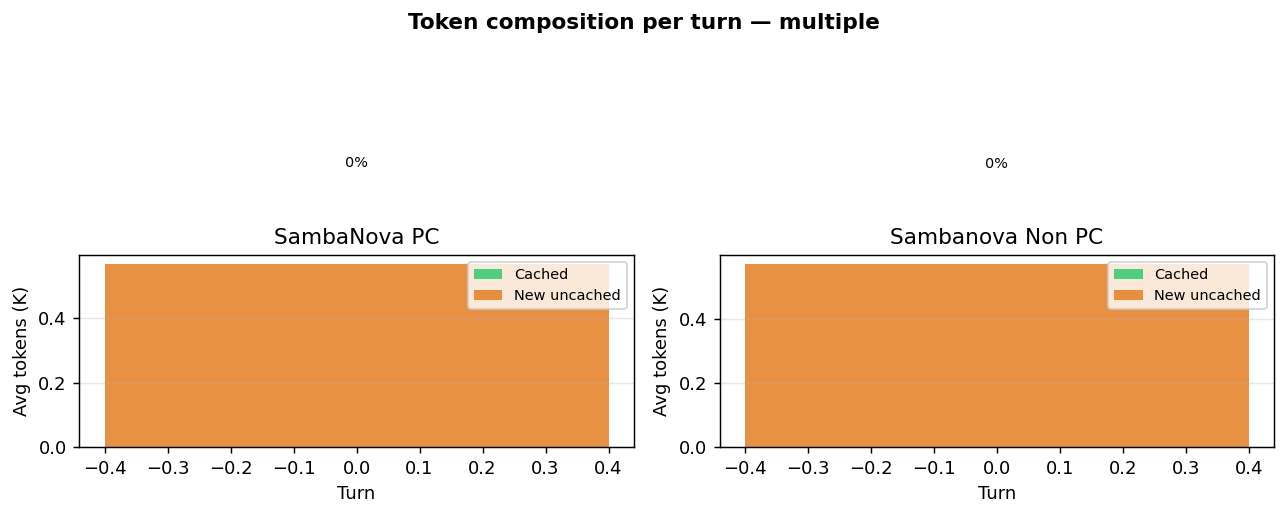

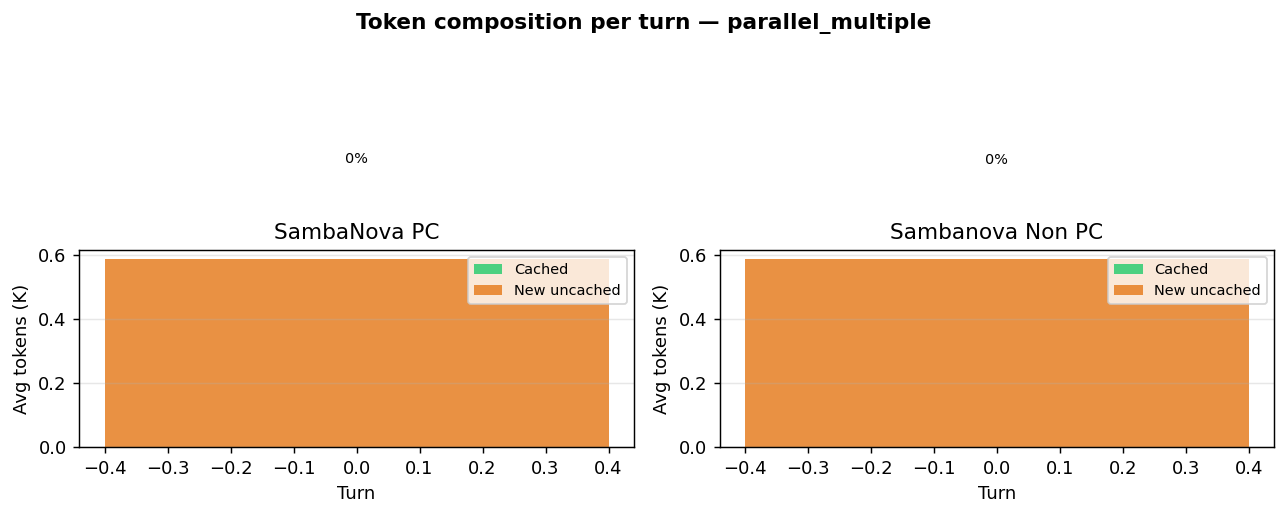

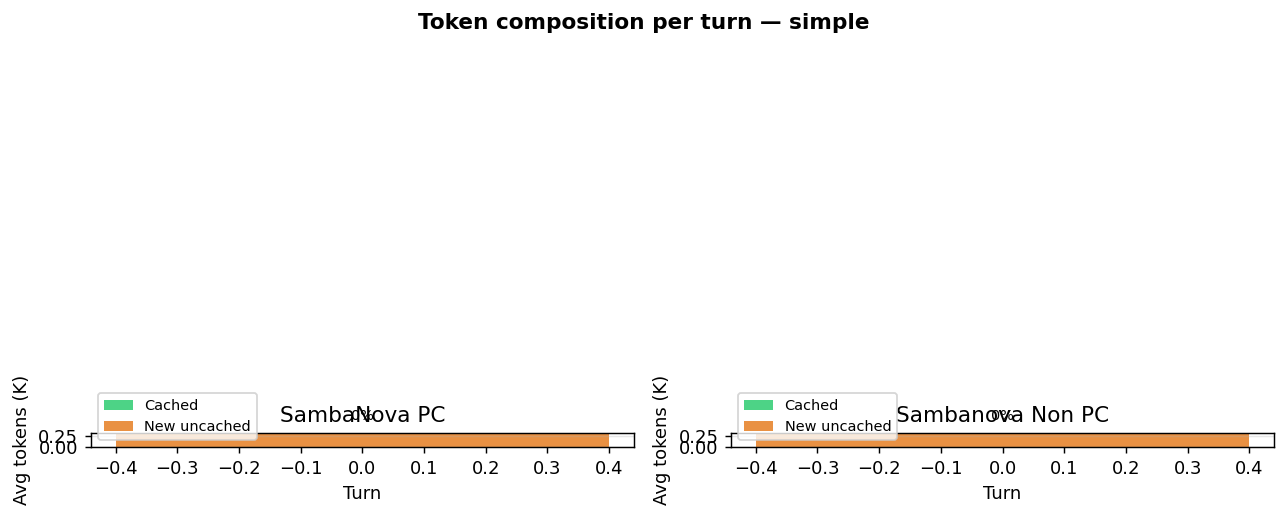

In [23]:
for cat in categories:
    cat_data = [d for d in DATA if d["category"] == cat]
    if not cat_data: continue
    fig, axes = plt.subplots(1, len(cat_data), figsize=(5 * len(cat_data), 4), squeeze=False)
    for col, d in enumerate(cat_data):
        ax = axes[0][col]
        ts = d["turn_stats"]
        turns  = [r["turn"]       for r in ts]
        cached = [r["avg_cached"] / 1000 for r in ts]
        new    = [r["avg_new"]    / 1000 for r in ts]
        ax.bar(turns, cached, label="Cached",      color="#2ecc71", alpha=0.85)
        ax.bar(turns, new,    label="New uncached", color="#e67e22", alpha=0.85, bottom=cached)
        for t, c, nw in zip(turns, cached, new):
            total = c + nw
            ax.text(t, total + 0.3, f"{c/total*100:.0f}%" if total > 0 else "", ha="center", fontsize=8)
        ax.set_xlabel("Turn"); ax.set_ylabel("Avg tokens (K)")
        ax.set_title(d["label"]); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    fig.suptitle(f"Token composition per turn — {cat}", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()

## 5 · Block alignment analysis
Spike near 100% reveals the physical KV block granularity.

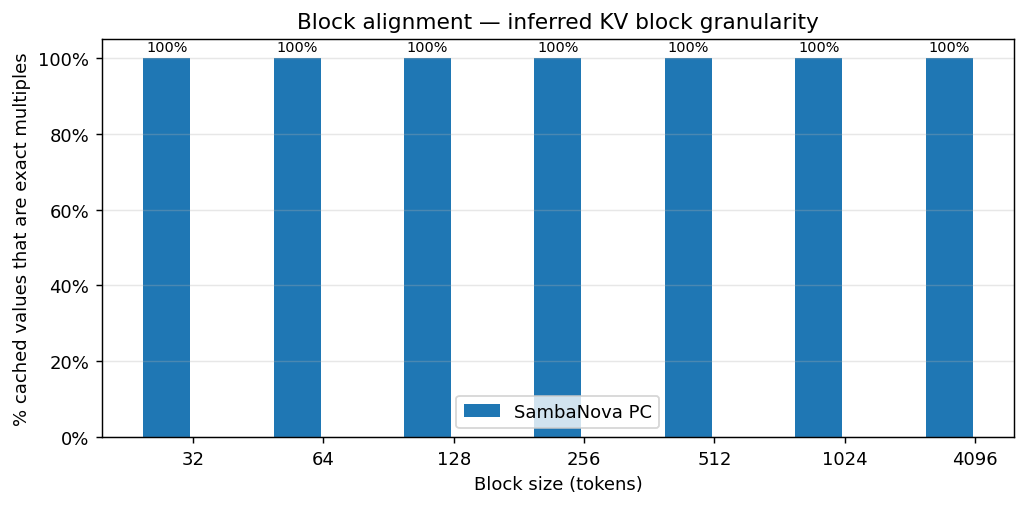


GCD of all cached values per provider:
  SambaNova PC: GCD = 4096


In [24]:
by_label = defaultdict(list)
for d in DATA:
    by_label[d["label"]].extend(d["step_cached"])

x = np.arange(len(BLOCK_SIZES))
width = 0.8 / max(len(run_labels), 1)
fig, ax = plt.subplots(figsize=(8, 4))
for i, lbl in enumerate(run_labels):
    vals = by_label[lbl]
    if not vals: continue
    pcts = [sum(1 for v in vals if v % b == 0) / len(vals) * 100 for b in BLOCK_SIZES]
    offset = (i - len(run_labels) / 2 + 0.5) * width
    bars = ax.bar(x + offset, pcts, width * 0.9, label=lbl)
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=8)

ax.set_xticks(x); ax.set_xticklabels([str(b) for b in BLOCK_SIZES])
ax.set_xlabel("Block size (tokens)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("% cached values that are exact multiples")
ax.set_title("Block alignment — inferred KV block granularity")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print("\nGCD of all cached values per provider:")
for lbl in run_labels:
    vals = by_label[lbl]
    if vals:
        g = vals[0]
        for v in vals[1:]: g = math.gcd(g, v)
        print(f"  {lbl}: GCD = {g}")

## 6 · Cached token remainder distribution
Spike at 0 = block-aligned caching. Flat histogram = token-level exact match (no alignment).

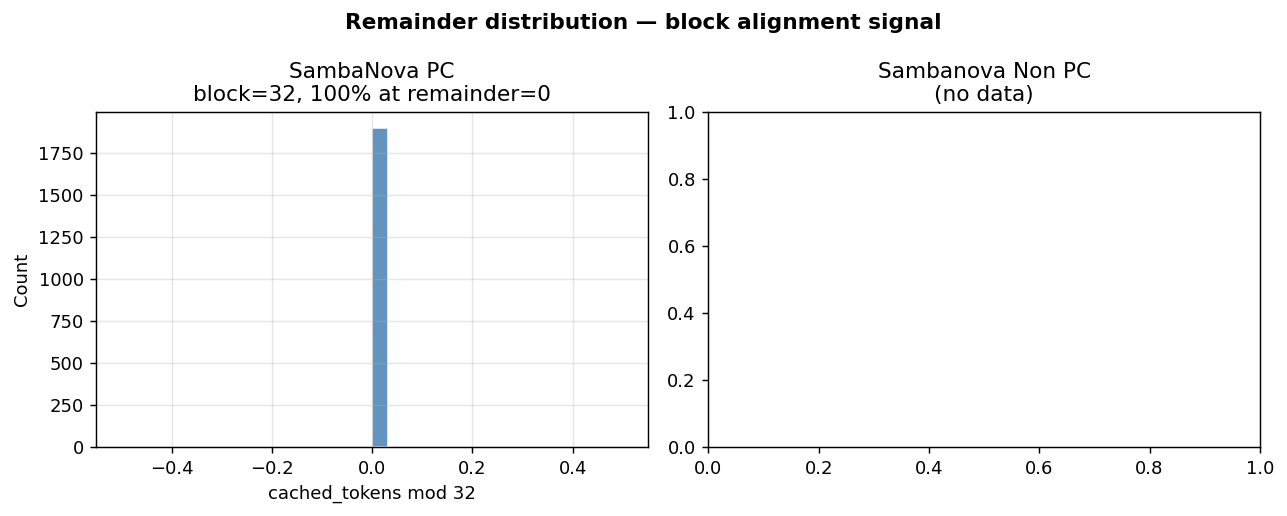

In [25]:
fig, axes = plt.subplots(1, len(run_labels), figsize=(5 * len(run_labels), 4), squeeze=False)
for col, lbl in enumerate(run_labels):
    ax = axes[0][col]
    vals = by_label[lbl]
    if not vals:
        ax.set_title(f"{lbl}\n(no data)"); continue
    best_block = max(BLOCK_SIZES, key=lambda b: sum(1 for v in vals if v % b == 0))
    remainders = [v % best_block for v in vals]
    zero_pct = remainders.count(0) / len(remainders) * 100
    ax.hist(remainders, bins=min(50, best_block), color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_xlabel(f"cached_tokens mod {best_block}")
    ax.set_ylabel("Count")
    ax.set_title(f"{lbl}\nblock={best_block}, {zero_pct:.0f}% at remainder=0")
    ax.grid(alpha=0.3)
fig.suptitle("Remainder distribution — block alignment signal", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 7 · Cache summary table

In [26]:
print(f"{'Provider':<28} {'Category':<30} {'Input(M)':>9} {'Output(M)':>9} {'Cached(M)':>10} {'Hit %':>7} {'Entries':>8}")
print("-" * 100)
for d in DATA:
    total_i = sum(flatten(e.get("input_token_count",  0)) for e in d["entries"])
    total_o = sum(flatten(e.get("output_token_count", 0)) for e in d["entries"])
    total_c = sum(flatten(e.get("cached_token_count", 0)) for e in d["entries"])
    hit = total_c / total_i * 100 if total_i > 0 else 0
    print(f"{d['label']:<28} {d['category']:<30} {total_i/1e6:>9.2f} {total_o/1e6:>9.2f} {total_c/1e6:>10.2f} {hit:>6.1f}% {len(d['entries']):>8}")

Provider                     Category                        Input(M) Output(M)  Cached(M)   Hit %  Entries
----------------------------------------------------------------------------------------------------
SambaNova PC                 live_parallel                       0.01      0.00       0.00    0.0%       16
SambaNova PC                 multi_turn_base                     6.68      0.14       4.26   63.7%      100
SambaNova PC                 multi_turn_long_context            12.20      0.18       8.47   69.4%      100
SambaNova PC                 multiple                            0.06      0.02       0.00    0.0%      100
SambaNova PC                 parallel_multiple                   0.06      0.04       0.00    0.0%      100
SambaNova PC                 simple                              0.03      0.03       0.00    0.0%      100
Sambanova Non PC             live_parallel                       0.01      0.00       0.00    0.0%       16
Sambanova Non PC             multi_

---
# Latency Analysis
`latency` field = wall-clock time per API call (seconds).  
- **TPOT** (Time Per Output Token) = latency / output_tokens × 1000 ms  
- **Throughput** = output_tokens / latency (tokens/sec)

## 8 · Avg latency, TPOT, and throughput by provider × category

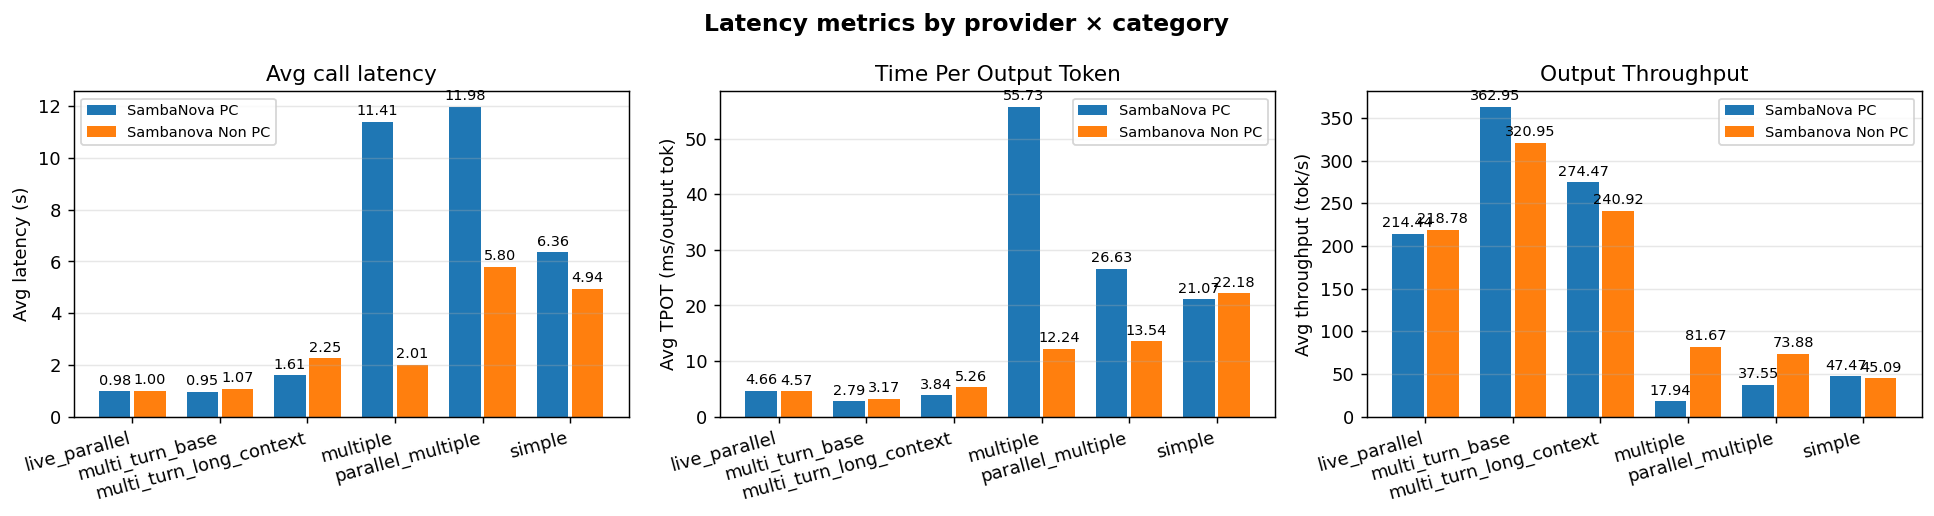

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metric_defs = [
    ("avg_latency",   "Avg latency (s)",         "Avg call latency"),
    ("avg_tpot_ms",   "Avg TPOT (ms/output tok)", "Time Per Output Token"),
    ("avg_throughput","Avg throughput (tok/s)",   "Output Throughput"),
]

def agg_ts(d, key):
    vals = [r[key] for r in d["turn_stats"] if r[key] > 0]
    return sum(vals) / len(vals) if vals else 0

x = np.arange(len(categories))
width = 0.8 / max(len(run_labels), 1)
for ax, (key, ylabel, title) in zip(axes, metric_defs):
    for i, lbl in enumerate(run_labels):
        vals = []
        for cat in categories:
            match = [d for d in DATA if d["label"] == lbl and d["category"] == cat]
            vals.append(agg_ts(match[0], key) if match else 0)
        offset = (i - len(run_labels) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width * 0.9, label=lbl)
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(categories, rotation=15, ha="right")
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

fig.suptitle("Latency metrics by provider × category", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 9 · Latency and TPOT per turn
Shows whether latency grows as context lengthens across turns.

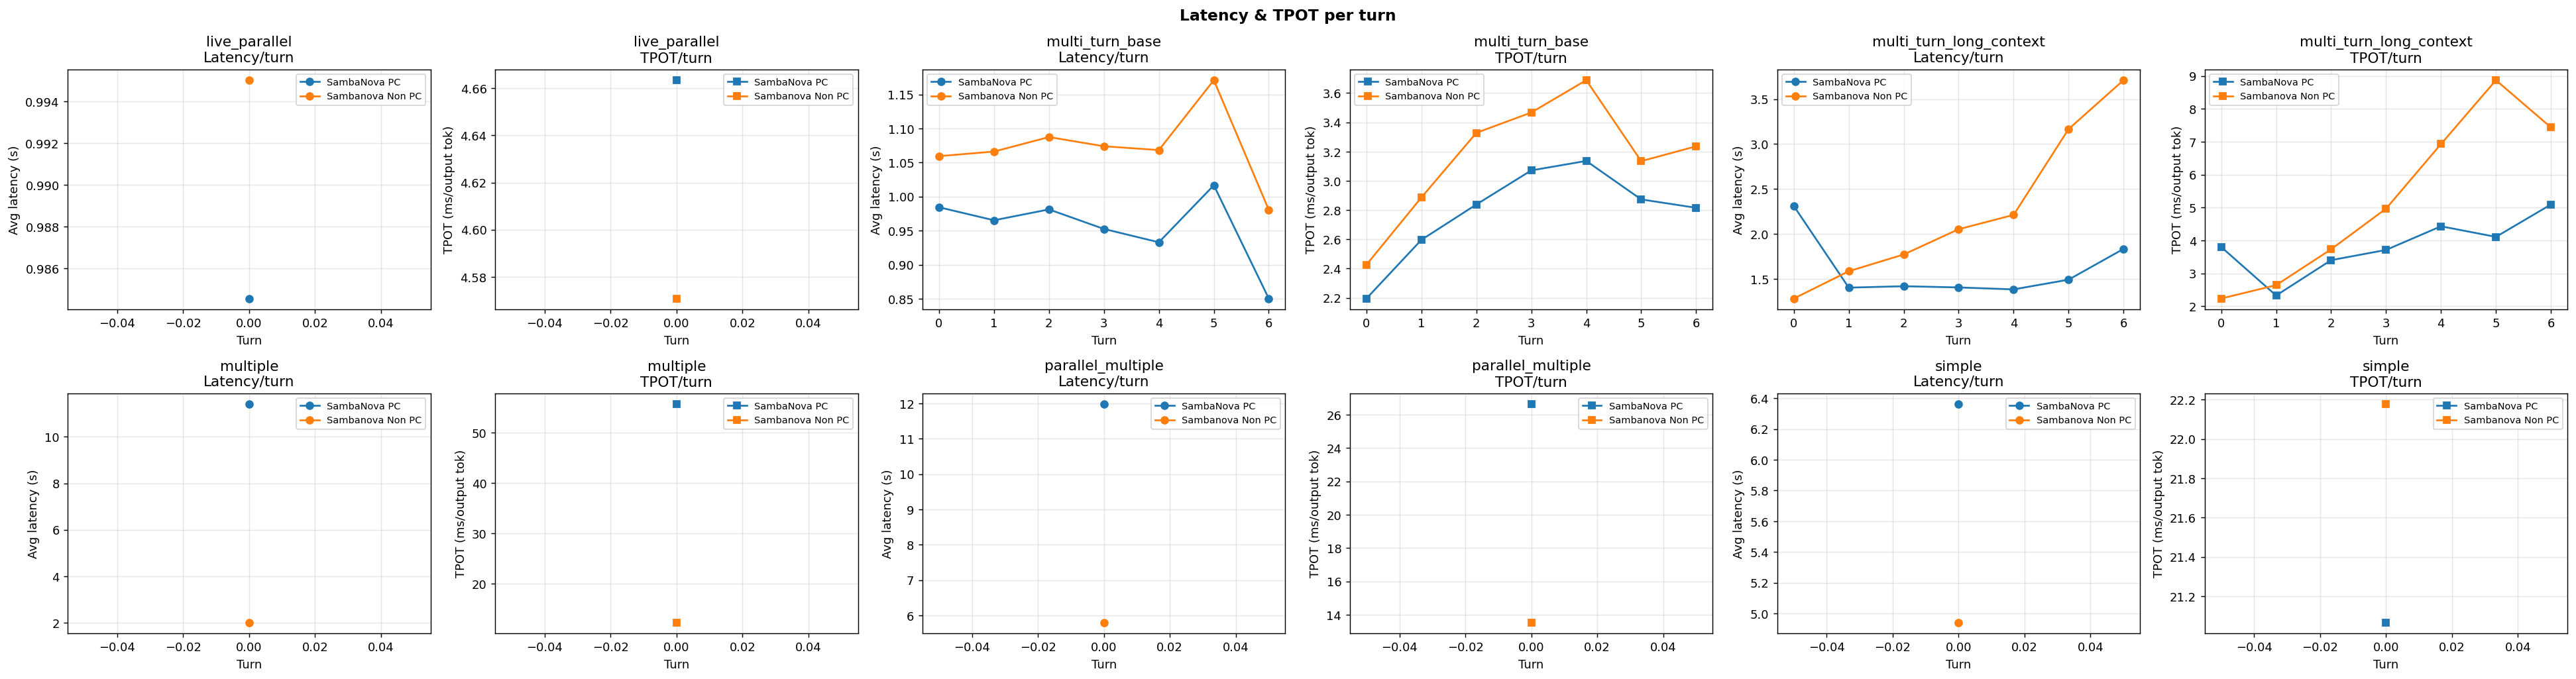

In [28]:
ncols = min(len(categories), 3)
nrows = math.ceil(len(categories) / ncols)
fig, axes = plt.subplots(nrows, ncols * 2, figsize=(5 * ncols * 2, 4 * nrows), squeeze=False)

for idx, cat in enumerate(categories):
    ax_lat  = axes[idx // ncols][(idx % ncols) * 2]
    ax_tpot = axes[idx // ncols][(idx % ncols) * 2 + 1]
    for d in DATA:
        if d["category"] != cat: continue
        ts    = d["turn_stats"]
        turns = [r["turn"]          for r in ts]
        lats  = [r["avg_latency"]   for r in ts]
        tpots = [r["avg_tpot_ms"]   for r in ts]
        thpts = [r["avg_throughput"] for r in ts]
        ax_lat.plot(turns,  lats,  marker="o", label=d["label"])
        ax_tpot.plot(turns, tpots, marker="s", label=d["label"])
    for ax, ylabel, title_suffix in [
        (ax_lat,  "Avg latency (s)",        "Latency/turn"),
        (ax_tpot, "TPOT (ms/output tok)",   "TPOT/turn"),
    ]:
        ax.set_xlabel("Turn"); ax.set_ylabel(ylabel)
        ax.set_title(f"{cat}\n{title_suffix}")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

for idx in range(len(categories), nrows * ncols):
    axes[idx // ncols][(idx % ncols) * 2].set_visible(False)
    axes[idx // ncols][(idx % ncols) * 2 + 1].set_visible(False)
fig.suptitle("Latency & TPOT per turn", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 10 · Latency distribution (box plot)
Spread of per-call latencies — spot tail latency differences between providers.

/var/folders/p4/y0q2kh796nx_k_yzfhxs57f00000gp/T/ipykernel_86381/3370697192.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True,
/var/folders/p4/y0q2kh796nx_k_yzfhxs57f00000gp/T/ipykernel_86381/3370697192.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True,
/var/folders/p4/y0q2kh796nx_k_yzfhxs57f00000gp/T/ipykernel_86381/3370697192.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True,
/var/folders/p4/y0q2kh796nx_k_yzfhxs57f00000gp/T/ipykernel

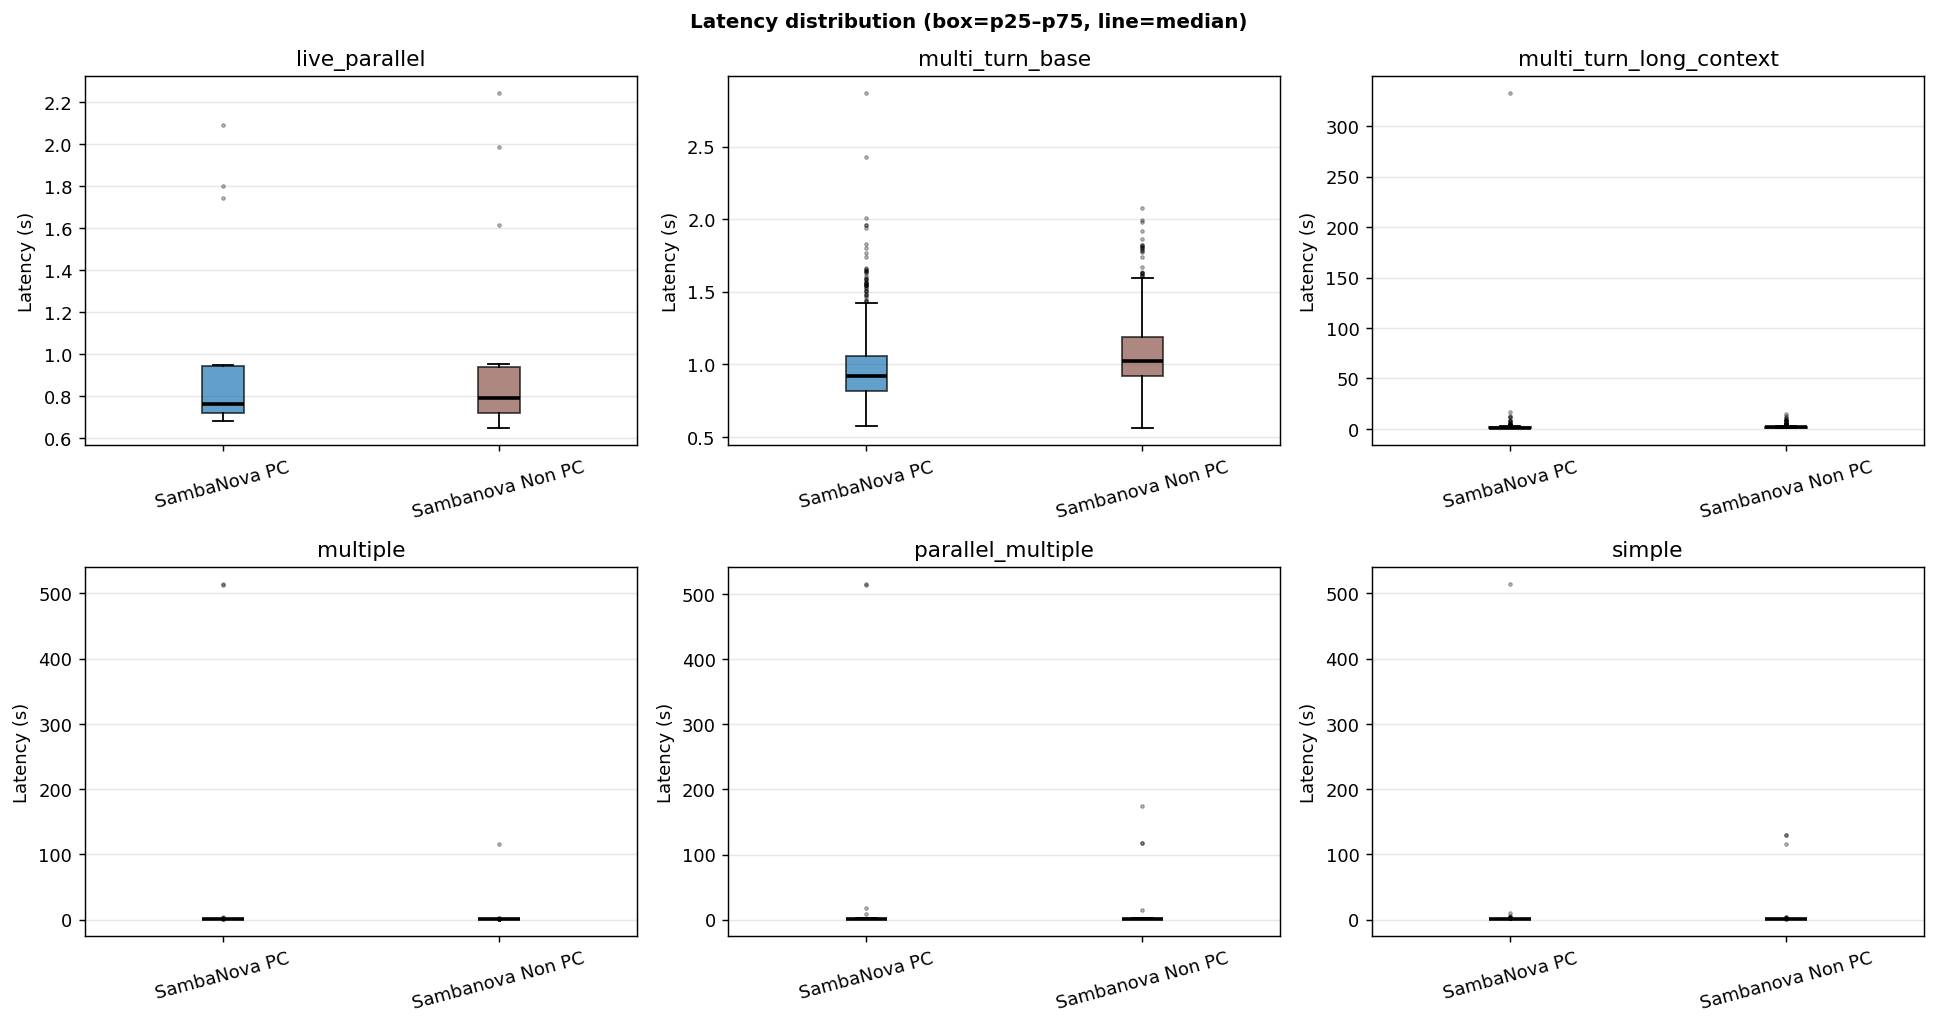

In [29]:
ncols = min(len(categories), 3)
nrows = math.ceil(len(categories) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for idx, cat in enumerate(categories):
    ax = axes[idx // ncols][idx % ncols]
    cat_data = [d for d in DATA if d["category"] == cat]
    box_data = [[l for l, o in d["step_pairs"]] for d in cat_data]
    labels   = [d["label"] for d in cat_data]
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=3, alpha=0.4))
    colors = plt.cm.tab10(np.linspace(0, 0.5, len(cat_data)))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_ylabel("Latency (s)"); ax.set_title(cat)
    ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.3)

for idx in range(len(categories), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)
fig.suptitle("Latency distribution (box=p25–p75, line=median)", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## 11 · Latency vs output tokens (scatter)
Linear scaling = healthy. Outliers above the trend = generation stalls or cold starts.

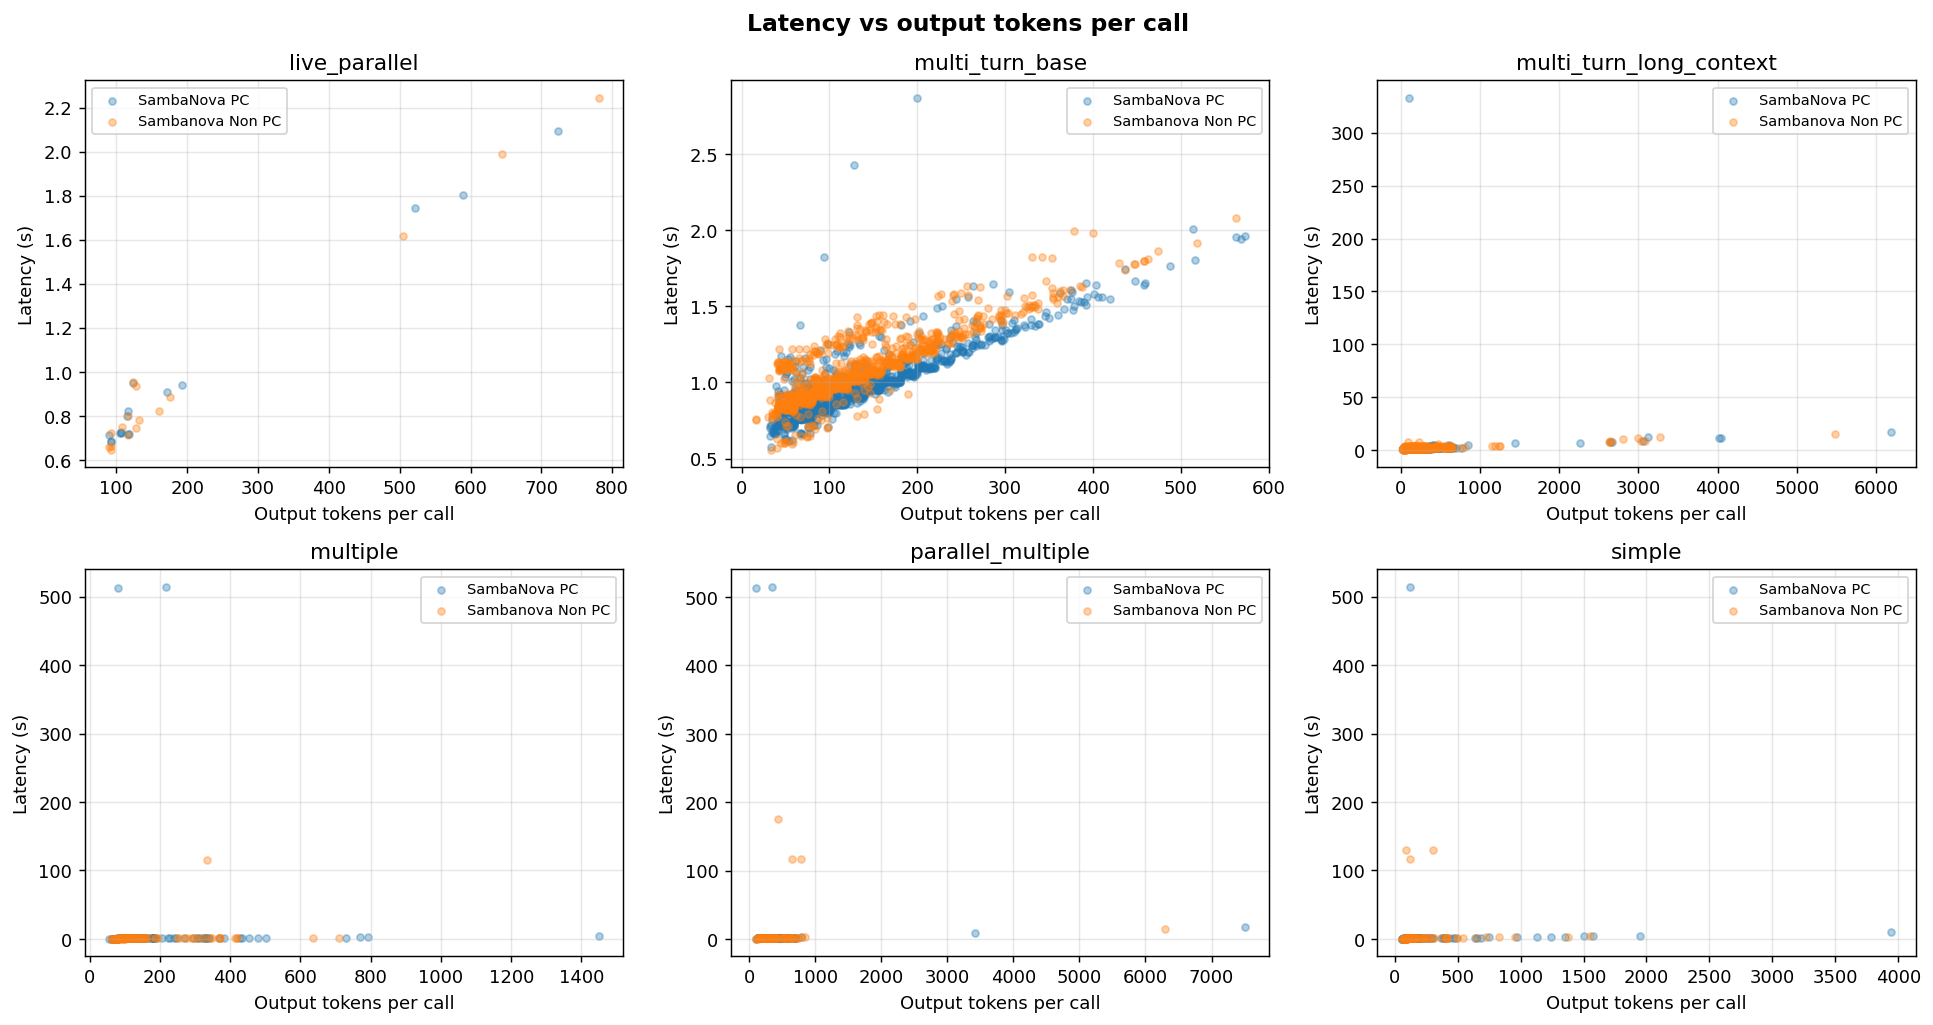

In [30]:
ncols = min(len(categories), 3)
nrows = math.ceil(len(categories) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for idx, cat in enumerate(categories):
    ax = axes[idx // ncols][idx % ncols]
    for d in DATA:
        if d["category"] != cat: continue
        pairs = d["step_pairs"]
        ax.scatter([o for l, o in pairs], [l for l, o in pairs],
                   label=d["label"], alpha=0.35, s=15)
    ax.set_xlabel("Output tokens per call"); ax.set_ylabel("Latency (s)")
    ax.set_title(cat); ax.legend(fontsize=8); ax.grid(alpha=0.3)

for idx in range(len(categories), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)
fig.suptitle("Latency vs output tokens per call", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 12 · Latency summary table

In [31]:
print(f"{'Provider':<28} {'Category':<30} {'Calls':>6} {'Avg(s)':>7} {'P50':>6} {'P90':>6} {'P99':>6} {'TPOT ms':>8} {'tok/s':>7}")
print("-" * 115)
for d in DATA:
    pairs = d["step_pairs"]
    if not pairs: continue
    lats = sorted(l for l, o in pairs)
    tpot_vals = [l / o * 1000 for l, o in pairs if o > 0]
    tput_vals = [o / l         for l, o in pairs if l > 0]
    print(
        f"{d['label']:<28} {d['category']:<30} {len(lats):>6} "
        f"{sum(lats)/len(lats):>6.2f}s "
        f"{percentile(lats,50):>5.2f}s "
        f"{percentile(lats,90):>5.2f}s "
        f"{percentile(lats,99):>5.2f}s "
        f"{sum(tpot_vals)/len(tpot_vals) if tpot_vals else 0:>8.1f} "
        f"{sum(tput_vals)/len(tput_vals) if tput_vals else 0:>7.1f}"
    )

Provider                     Category                        Calls  Avg(s)    P50    P90    P99  TPOT ms   tok/s
-------------------------------------------------------------------------------------------------------------------
SambaNova PC                 live_parallel                      16   0.98s  0.80s  1.80s  2.09s      6.1   183.7
SambaNova PC                 multi_turn_base                  1027   0.97s  0.92s  1.25s  1.66s      9.0   130.1
SambaNova PC                 multi_turn_long_context          1008   1.68s  1.11s  2.03s  4.63s     14.1   116.7
SambaNova PC                 multiple                           98  11.41s  0.81s  1.47s 514.09s     93.6   188.5
SambaNova PC                 parallel_multiple                  98  11.98s  1.26s  1.97s 514.92s     73.9   258.6
SambaNova PC                 simple                             99   6.36s  0.80s  2.17s 514.14s     48.1   195.2
Sambanova Non PC             live_parallel                      16   1.00s  0.80s  1.99s  